# Instagram Fake vs Genuine Account Detection (ML Classification)

---

## Problem Statement

Social media platforms such as Instagram are increasingly affected by fake accounts that spread spam, misinformation, scams, and fraudulent activities. The objective of this project is to develop a machine learning model that can accurately classify Instagram accounts as **Fake** or **Genuine** based on profile features, helping improve platform security and user trust.
- **1 = Fake**
- **0 = Genuine**

## Dataset
Data Source: https://www.kaggle.com/datasets/free4ever1/instagram-fake-spammer-genuine-accounts

## End-to-End workflow:
1. Data Understanding  
2. Data Cleaning  
3. EDA  
4. Feature Engineering  
5. Train/Validation Split (Stratified)  
6. Baseline + Modeling  
7. Evaluation (F1, Confusion Matrix, Report)  
8. Cross-Validation (stability check)  
9. Feature Importance / Interpretability  
10. Final Model + Test Predictions  
11. Conclusion + Future Improvements


In [41]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

# Settings (clean plots)
sns.set_theme(style="whitegrid")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
RANDOM_STATE = 42


## 1. Data Understanding

- `train.csv` (includes the target column `fake`)
- `test.csv` (no target; used only for final predictions)


In [42]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (576, 12)
Test shape: (120, 12)


,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.33,1,0.33,1,30,0,1,35,488,604,0
1,1,0.00,5,0.00,0,64,0,1,3,35,6,0
2,1,0.00,2,0.00,0,82,0,1,319,328,668,0
3,1,0.00,1,0.00,0,143,0,1,273,14890,7369,0
4,1,0.50,1,0.00,0,76,0,1,6,225,356,0


Inspect datatypes and basic summary statistics to understand feature ranges and spot anomalies.

In [43]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    int64  
 11  fake                  576 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 54.1 KB


In [44]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
profile pic,576.0,0.701389,0.458047,0.0,0.0,1.0,1.00,1.00
nums/length username,576.0,0.163837,0.214096,0.0,0.0,0.0,0.31,0.92
fullname words,576.0,1.460069,1.052601,0.0,1.0,1.0,2.00,12.00
nums/length fullname,576.0,0.036094,0.125121,0.0,0.0,0.0,0.00,1.00
name==username,576.0,0.034722,0.183234,0.0,0.0,0.0,0.00,1.00
description length,576.0,22.623264,37.702987,0.0,0.0,0.0,34.00,150.00
external URL,576.0,0.116319,0.320886,0.0,0.0,0.0,0.00,1.00
private,576.0,0.381944,0.486285,0.0,0.0,0.0,1.00,1.00
#posts,576.0,107.489583,402.034431,0.0,0.0,9.0,81.50,7389.00
#followers,576.0,85307.236111,910148.457657,0.0,39.0,150.5,716.00,15338538.00


In [45]:
train_df.nunique()

profile pic               2
nums/length username     54
fullname words            9
nums/length fullname     25
name==username            2
description length      104
external URL              2
private                   2
#posts                  193
#followers              372
#follows                400
fake                      2
dtype: int64

## 2. Data Cleaning

To handle:
- Missing values 
- Duplicate rows 


In [46]:
# Missing values
missing = train_df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

Series([], dtype: int64)

In [47]:
# Duplicate rows
train_dup_count = train_df.duplicated().sum()
test_dup_count = test_df.duplicated().sum()

print("Duplicate rows in train:", train_dup_count)
print("Duplicate rows in test:", test_dup_count)

# Remove duplicates from train dataset
if train_dup_count > 0:
    train_df = train_df.drop_duplicates()

# Remove duplicates from test dataset
if test_dup_count > 0:
    test_df = test_df.drop_duplicates()

print("Train shape after dropping duplicates:", train_df.shape)
print("Test shape after dropping duplicates:", test_df.shape)

Duplicate rows in train: 2
Duplicate rows in test: 2
Train shape after dropping duplicates: (574, 12)
Test shape after dropping duplicates: (118, 12)


In [48]:
train_df.dtypes

profile pic               int64
nums/length username    float64
fullname words            int64
nums/length fullname    float64
name==username            int64
description length        int64
external URL              int64
private                   int64
#posts                    int64
#followers                int64
#follows                  int64
fake                      int64
dtype: object

## 3. Exploratory Data Analysis (EDA)
- Understand target distribution
- Understand feature distributions
- Spot outliers / skew
- Check correlation patterns (not to remove features blindly, but to understand relationships)


### Target distribution

Checking class balance helps choose the right evaluation metric and modeling settings (e.g., `class_weight='balanced'`).

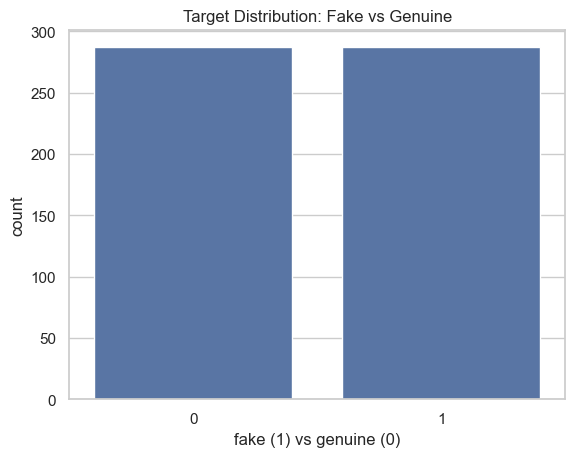

fake
0    0.5
1    0.5
Name: proportion, dtype: float64

In [49]:
ax = sns.countplot(x="fake", data=train_df)
ax.set_title("Target Distribution: Fake vs Genuine")
ax.set_xlabel("fake (1) vs genuine (0)")
ax.set_ylabel("count")
plt.show()

train_df["fake"].value_counts(normalize=True).rename("proportion")

The dataset shows an equal distribution of fake (1) and genuine (0) accounts, indicating a well-balanced target variable.
This balance reduces the risk of model bias toward one class and allows the classifier to learn patterns for both categories effectively.
#####

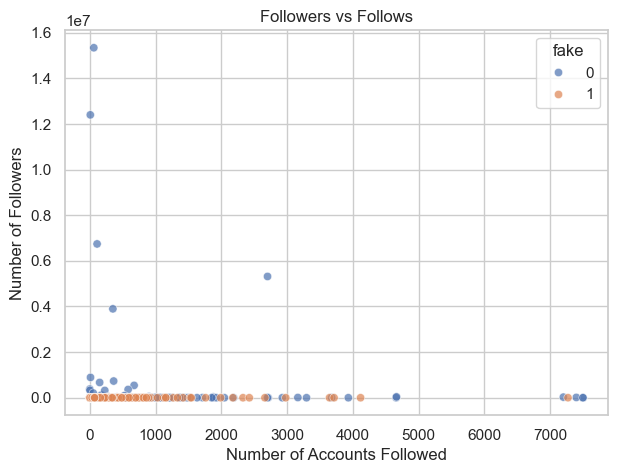

In [50]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=train_df["#follows"], y=train_df["#followers"], hue=train_df["fake"], alpha=0.7)
plt.title("Followers vs Follows")
plt.xlabel("Number of Accounts Followed")
plt.ylabel("Number of Followers")
plt.show()

Fake accounts tend to follow a large number of accounts while having relatively few followers, creating an imbalanced relationship.
Genuine accounts generally show a more balanced follower-following pattern, reflecting authentic social engagement.
#####

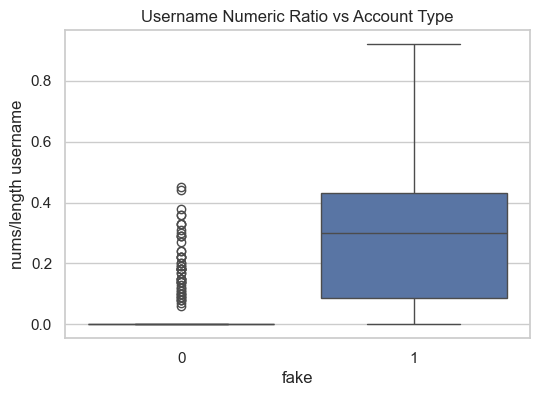

In [51]:
plt.figure(figsize=(6,4))
sns.boxplot(x="fake", y="nums/length username", data=train_df)
plt.title("Username Numeric Ratio vs Account Type")
plt.show()

Fake accounts tend to have a higher proportion of numeric characters in their usernames.
This pattern suggests automated or randomly generated usernames commonly used by bot accounts.
#####

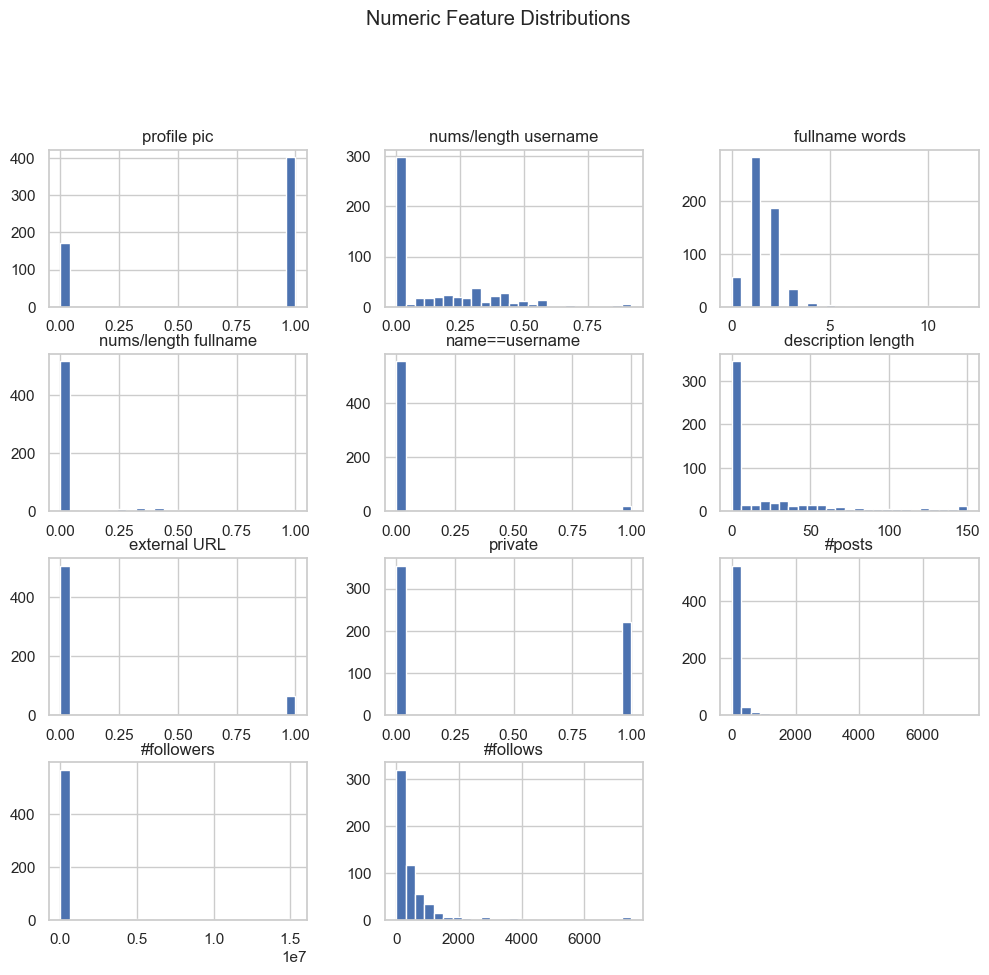

In [52]:
# Distribution of a few key numeric columns (adjust list if your dataset differs)
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude target for feature-only plots
num_feature_cols = [c for c in num_cols if c != "fake"]

train_df[num_feature_cols].hist(bins=25, figsize=(12, 10))
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.show()

Most numerical features exhibit right-skewed distributions, with a large concentration of values near zero and a few extreme outliers, particularly in followers, follows, and posts.
This suggests that while most accounts have low activity or engagement levels, a small number of accounts show significantly higher values, which may influence model behavior.
#####

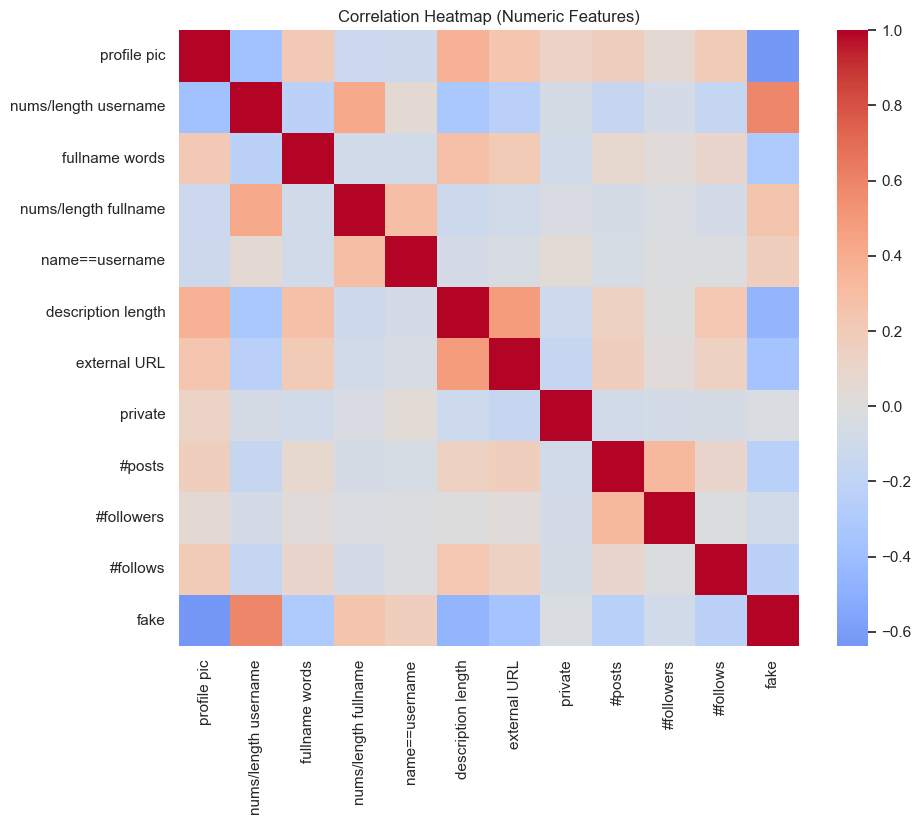

In [53]:
# Correlation heatmap (numeric only)
plt.figure(figsize=(10, 8))
corr = train_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

The correlation heatmap shows generally weak to moderate relationships among most features, indicating limited multicollinearity within the dataset.
Some features such as username characteristics and description length display moderate correlation with the target variable, suggesting potential predictive importance for detecting fake accounts.
#####

## 4. Feature Engineering 

**Objective:**
Create meaningful derived features that capture relationships between profile attributes. These engineered features may help the machine learning model better distinguish fake Instagram accounts from genuine ones.  

-  **Followers-to-Following Ratio:** Measures the relationship between followers and following count. Genuine accounts generally exhibit more balanced ratios, whereas fake accounts often follow many users while having relatively few followers.
- **Posts per Follower:** Represents posting activity relative to audience size. Extremely high or low values may indicate unusual account behavior.

To ensure numerical stability, **1 is added to the denominator** when calculating ratios to prevent division-by-zero errors for accounts with zero followers or zero following.

In [54]:
# Create copies of the original datasets to preserve raw data
train_features = train_df.copy()
test_features = test_df.copy()


# Function to create engineered features
def create_features(data):
    """
    Create domain-specific features for Instagram account classification.

    Features:
    - followers_following_ratio
    - posts_per_follower

    A value of 1 is added to the denominator to prevent division-by-zero errors.
    """
    data = data.copy()

    # Followers-to-Following Ratio
    data["followers_following_ratio"] = (
        data["#followers"] / (data["#follows"] + 1)
    )
    
    # Posts per Follower
    data["posts_per_follower"] = (
        data["#posts"] / (data["#followers"] + 1)
    )

    return data

# Apply feature engineering to both datasets
train_features = create_features(train_features)
test_features = create_features(test_features)

# Separate features and target variable
X = train_features.drop(columns=["fake"])
y = train_features["fake"]

# Prepare test features
test_features = test_features.drop(columns=["fake"], errors="ignore")

# Display the newly created features
print("Engineered Features Preview:\n")

train_features[
    [
        "followers_following_ratio",
        "posts_per_follower"
    ]
].head()

Engineered Features Preview:



,followers_following_ratio,posts_per_follower
0,1.046025,0.031968
1,5.131086,0.104341
2,1.606061,0.081250
3,0.634969,1.636145
4,1.188976,0.039474


## 5. Train-Validation Split 

- Split the dataset into training and validation sets.
- **Stratified sampling** preserves the original class balance in both train and validation splits.
- variable in both subsets, ensuring a representative evaluation.

In [55]:
# Train-Validation Split


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training Set Shape :", X_train.shape)
print("Validation Set Shape:", X_valid.shape)

Training Set Shape : (459, 13)
Validation Set Shape: (115, 13)


## 6. Baseline Model 

- A baseline tells us whether our ML model actually adds value.
- Train a Dummy Classifier to establish a baseline performance.
- The model always predicts the majority class ("most_frequent").
- Any machine learning model developed later should outperform this baseline.

In [56]:
dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

dummy.fit(X_train, y_train)

# Generate predictions on the validation set
dummy_pred = dummy.predict(X_valid)

# Evaluate baseline performance using the F1-score
baseline_f1 = f1_score(y_valid, dummy_pred)

print(f"Baseline F1-Score: {baseline_f1:.4f}")

Baseline F1-Score: 0.6628


Before training machine learning models, a baseline model is established using a DummyClassifier. The baseline always predicts the majority class and serves as a minimum performance benchmark. Any trained model should achieve a higher F1-score than this baseline to demonstrate meaningful predictive capability.  

## 7. Modeling

We train two models:

1. **Logistic Regression (with feature scaling)**  
   - Interpretable baseline for tabular classification  
   - Uses `StandardScaler` in a `Pipeline` to avoid convergence issues and prevent data leakage
   - Class weights are balanced to account for class imbalance.  

Logistic Regression is used as the first machine learning model due to its simplicity, interpretability, and strong performance on binary classification tasks. Since the algorithm is sensitive to feature scales, StandardScaler is applied within a Pipeline to prevent data leakage. Class weights are balanced to improve performance on imbalanced classes.

In [57]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

# Train the model
logistic_pipeline.fit(X_train, y_train)

# Generate predictions
logistic_predictions = logistic_pipeline.predict(X_valid)

# Evaluate the model
logistic_f1 = f1_score(y_valid, logistic_predictions)

print(f"Logistic Regression F1-Score: {logistic_f1:.4f}")

Logistic Regression F1-Score: 0.9074


#####
**2. Random Forest**  
- Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.
- Feature scaling is not required for tree-based models.  
  
Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions to improve generalization and reduce overfitting. Unlike Logistic Regression, it does not require feature scaling and is capable of capturing complex, non-linear relationships within the data.

In [58]:
# Model 2: Random Forest (controlled complexity)

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Generate predictions
random_forest_predictions = random_forest_model.predict(X_valid)

# Evaluate the model
random_forest_f1 = f1_score(y_valid, random_forest_predictions)

print(f"Random Forest F1-Score: {random_forest_f1:.4f}")

Random Forest F1-Score: 0.9474


## 8. Evaluation

We report:
- **Classification report** (precision, recall, F1)
- **Confusion matrix** (error types)


**Logistic Regression Evaluation**
- Evaluate the model using a classification report and confusion matrix.
- The classification report summarizes Precision, Recall, F1-Score, and
- Accuracy, while the confusion matrix visualizes prediction performance.

=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        58
           1       0.96      0.86      0.91        57

    accuracy                           0.91       115
   macro avg       0.92      0.91      0.91       115
weighted avg       0.92      0.91      0.91       115



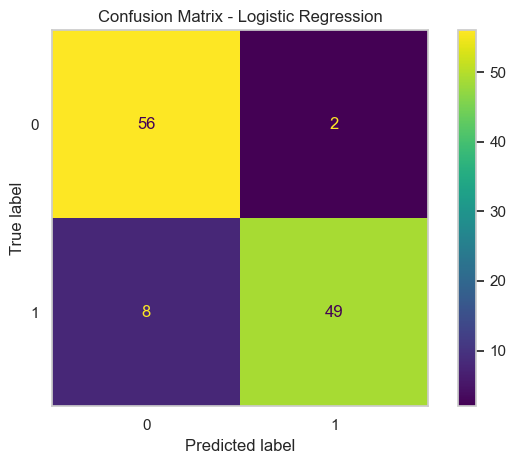

In [59]:
# Generate predictions
logistic_predictions = logistic_pipeline.predict(X_valid)

# Classification Report
print("=== Logistic Regression Report ===")

print(classification_report(y_valid, logistic_predictions))

# Confusion Matrix
cm = confusion_matrix(y_valid, logistic_predictions)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(
    values_format="d"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.grid(False)
plt.tight_layout()
plt.show()

The Logistic Regression model achieved an accuracy of 91% with a weighted F1-score of 0.91, demonstrating strong and balanced performance in classifying fake and genuine Instagram accounts. The confusion matrix shows that the model correctly classified most accounts, with only a few misclassifications.  
#####

**Random Forest Evaluation**  
- Evaluate the Random Forest model using a classification report and confusion matrix.


=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        58
           1       0.95      0.95      0.95        57

    accuracy                           0.95       115
   macro avg       0.95      0.95      0.95       115
weighted avg       0.95      0.95      0.95       115



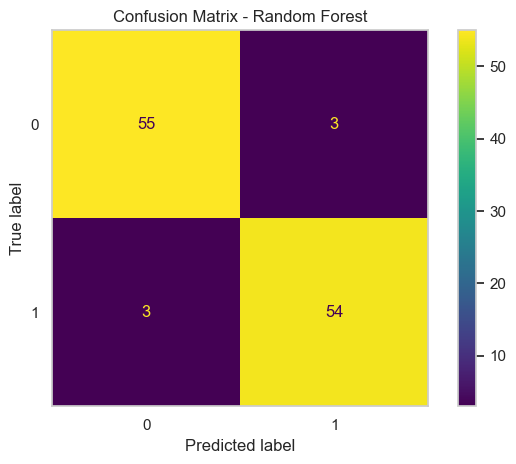

In [60]:
print("=== Random Forest Report ===")

print(classification_report(y_valid, random_forest_predictions))

# Confusion Matrix
cm = confusion_matrix(y_valid, random_forest_predictions)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(
    values_format="d"
)

plt.title("Confusion Matrix - Random Forest")
plt.grid(False)
plt.tight_layout()
plt.show()

The Random Forest model achieved an accuracy of 95% with a weighted F1-score of 0.95, demonstrating excellent and balanced performance in classifying both fake and genuine Instagram accounts. The confusion matrix shows that the model correctly classified 109 out of 115 accounts, with only 6 misclassifications, indicating high predictive reliability.  
#####

## 9. Cross-Validation of Random Forest Model (Stability Check)

Cross-validation is used to evaluate the model's performance on different subsets of the dataset, ensuring that the results are reliable and not dependent on a single train-test split.

In this project:

- **5-fold Cross-Validation** is used to divide the dataset into five equal parts.
- The model is trained on four folds and validated on the remaining fold.
- This process is repeated five times so that each fold is used once as the validation set.
- The **F1-score** is selected as the evaluation metric because it balances **Precision** and **Recall**, making it suitable for fake account detection.
- The **Mean F1-score** represents the overall model performance across all folds.
- The **Standard Deviation (Std)** indicates the consistency of the model. A lower standard deviation suggests that the model performs consistently across different data splits.

In [61]:
rf_cv_scores = cross_val_score(
    random_forest_model,
    X, y,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("RF CV F1 scores:", np.round(rf_cv_scores, 4))
print("RF Mean CV F1:", round(rf_cv_scores.mean(), 4))
print("RF Std CV F1:", round(rf_cv_scores.std(), 4))

RF CV F1 scores: [0.9735 0.9189 0.8785 0.9915 0.9167]
RF Mean CV F1: 0.9358
RF Std CV F1: 0.0411


The Random Forest model achieved an average F1-score of 93.58%, indicating excellent performance in distinguishing fake and genuine Instagram accounts. The low standard deviation (0.0411) suggests that the model performs consistently across different folds, demonstrating good stability and generalization.

## 10. Hyperparameter Tuning using Grid Search

Hyperparameter tuning is performed to identify the optimal combination of Random Forest parameters that maximizes model performance.

In this project:

- **GridSearchCV** systematically evaluates multiple combinations of hyperparameters.
- **5-fold Stratified Cross-Validation** is used to ensure that each fold maintains a similar distribution of fake and genuine Instagram accounts.
- The **F1-score** is selected as the evaluation metric because it balances Precision and Recall, making it suitable for fake account detection.
- The model with the highest average cross-validation F1-score is selected as the final optimized Random Forest model.

### Tuned Hyperparameters

- **n_estimators:** Number of decision trees in the forest.
- **max_depth:** Maximum depth of each decision tree.
- **min_samples_leaf:** Minimum number of samples required at each leaf node.

The best-performing hyperparameter combination is chosen based on the highest average F1-score obtained during cross-validation.

In [62]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2]
}

rf_for_search = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

grid = GridSearchCV(
    estimator=rf_for_search,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation F1 Score:", round(grid.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 400}
Best Cross-Validation F1 Score: 0.9276


Grid Search evaluated 12 different hyperparameter combinations using 5-fold cross-validation, resulting in a total of 60 model training and evaluation runs. This exhaustive search helps identify the hyperparameter combination that provides the best overall F1-score.

## 11. Evaluation of the Tuned Random Forest Model

After identifying the optimal hyperparameters using Grid Search, the best-performing Random Forest model is retrained on the training dataset and evaluated on the validation dataset.

The model's performance is assessed using:

- **F1-Score:** Measures the balance between Precision and Recall, making it suitable for fake account detection.
- **Classification Report:** Provides Precision, Recall, F1-score, and Support for each class.
- **Confusion Matrix:** Visualizes the number of correct and incorrect predictions, helping identify True Positives, True Negatives, False Positives, and False Negatives.

These evaluation metrics provide a comprehensive understanding of the tuned model's predictive performance and its ability to distinguish between fake and genuine Instagram accounts.


Tuned Random Forest Validation F1 Score: 0.9474

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        58
           1       0.95      0.95      0.95        57

    accuracy                           0.95       115
   macro avg       0.95      0.95      0.95       115
weighted avg       0.95      0.95      0.95       115



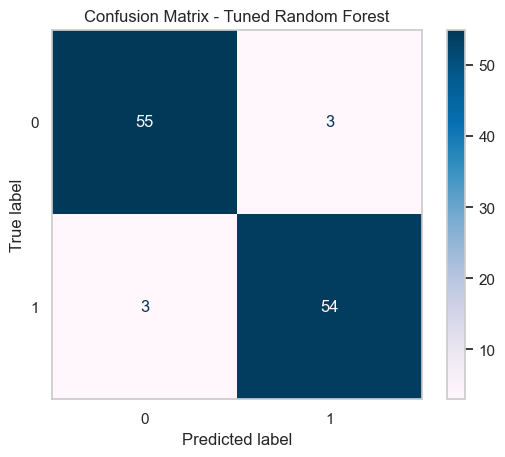

In [63]:
best_rf = grid.best_estimator_

# Train the best model
best_rf.fit(X_train, y_train)

# Make predictions
best_pred = best_rf.predict(X_valid)

# Evaluate model
best_f1 = f1_score(y_valid, best_pred)

print(f"Tuned Random Forest Validation F1 Score: {best_f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_valid, best_pred))

# Confusion Matrix
cm = confusion_matrix(y_valid, best_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="PuBu")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.grid(False)
plt.show()

The tuned Random Forest model achieved an F1-score and overall accuracy of 94.74%, demonstrating excellent performance in distinguishing fake and genuine Instagram accounts. The confusion matrix shows that the model correctly classified 109 out of 115 accounts, with only 6 misclassifications, indicating high predictive accuracy and balanced performance across both classes.

## 12. Feature Importance

Feature importance analysis is performed to identify the most influential features used by the tuned Random Forest model for predicting whether an Instagram account is fake or genuine.

Random Forest calculates feature importance based on the contribution of each feature toward reducing impurity across all decision trees.

The horizontal bar chart displays the **Top 15 most important features**, ranked according to their importance scores.

This analysis helps:

- Identify the features that contribute most to the prediction.
- Improve the interpretability of the model.
- Understand which account characteristics are most useful for detecting fake Instagram accounts.
- Support future feature selection and model optimization.

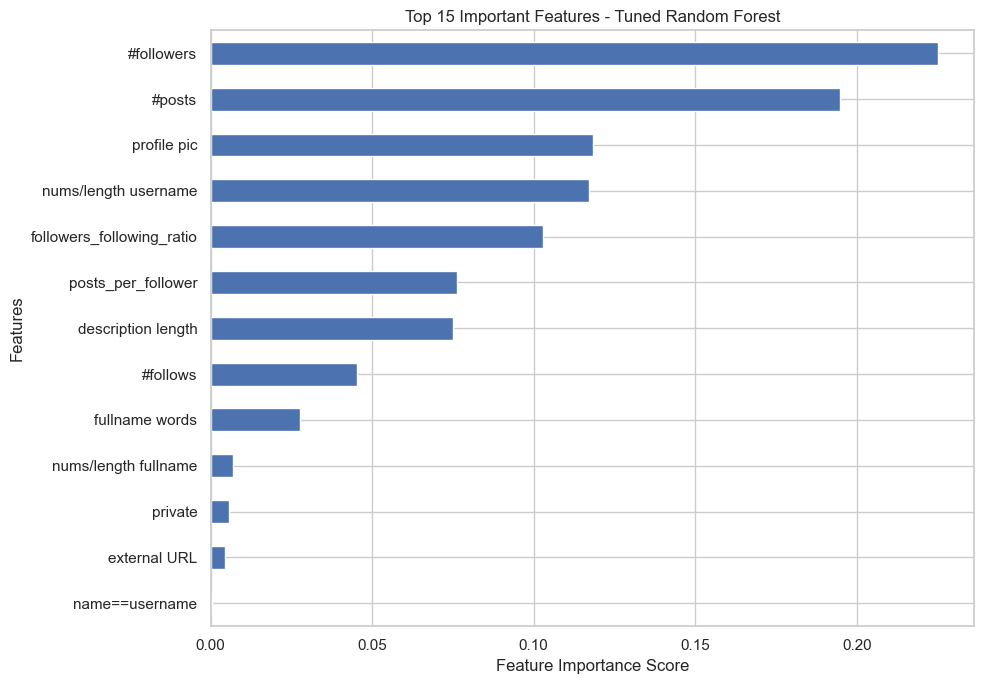

Top 10 Most Important Features:
#followers                   0.225034
#posts                       0.194689
profile pic                  0.118374
nums/length username         0.117085
followers_following_ratio    0.102774
posts_per_follower           0.076157
description length           0.075168
#follows                     0.045374
fullname words               0.027813
nums/length fullname         0.006929
dtype: float64


In [64]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot Top 15 Important Features
plt.figure(figsize=(10, 7))

importances.head(15).sort_values().plot(
    kind="barh",
)

plt.title("Top 15 Important Features - Tuned Random Forest")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

top_features = importances.head(10)

print("Top 10 Most Important Features:")
print(top_features)


The feature importance analysis indicates that **`#followers`**, **`#posts`**, and **`profile pic`** are the most influential features in predicting whether an Instagram account is fake or genuine. Features such as **`external URL`**, **`private`**, and **`name==username`** have minimal impact on the model, contributing very little to the final predictions.


## 13. Final Model Training and Test Prediction

After identifying the optimal hyperparameters through Grid Search, the best-performing Random Forest model is retrained using the **entire training dataset**. Training on the complete dataset allows the model to learn from all available information before making predictions on unseen data.

The trained model is then used to generate predictions for the test dataset. These predictions are stored in a submission DataFrame, which can be exported as a CSV file for further evaluation, deployment, or competition submission.

In [65]:
# Train the final model on the complete training dataset
final_model = grid.best_estimator_
final_model.fit(X, y)

# Generate predictions on the test dataset
test_pred = final_model.predict(test_features)

# Create submission dataframe
submission = pd.DataFrame({
    "Prediction": test_pred
})

# Preview predictions
submission.head()

,Prediction
0,0
1,0
2,0
3,0
4,1


## Conclusion
- Successfully developed a Random Forest-based machine learning model to classify Instagram accounts as Fake or Genuine.
- Performed data preprocessing, feature selection, model training, cross-validation, and hyperparameter tuning to improve model performance.
- The tuned Random Forest model achieved an F1-score of 94.74%, demonstrating excellent predictive performance.
- Feature importance analysis identified number of followers, number of posts, and profile picture as the most influential features for classification.
- The final model generated reliable predictions on unseen test data, showing good generalization capability.
---- 

## Future Improvements
- Collect a larger and more diverse dataset to improve model robustness.
- Experiment with advanced models such as XGBoost, LightGBM, or CatBoost for potentially higher accuracy.
- Incorporate additional features such as posting frequency, engagement rate, caption analysis, and image-based features.
- Develop a real-time web application using Streamlit or Flask for instant fake account detection.
- Continuously retrain the model with new Instagram data to adapt to evolving fake account behaviors.
---  

## Project Summary
- Built a machine learning solution to detect fake and genuine Instagram accounts.
- Applied data preprocessing, model evaluation, cross-validation, and hyperparameter tuning to optimize performance.
- Achieved a high-performing Random Forest model with a validation F1-score of 94.74%.
- Analyzed feature importance to understand the factors influencing predictions.
- The project demonstrates how machine learning can enhance social media security by automatically identifying suspicious Instagram accounts.